In [69]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, make_smoothing_spline
from scipy.integrate import cumulative_trapezoid
import torch
import torch.nn.functional as _F

from plot_style import set_style, C, vline
from utils import bs_call_price, mc_iv, bs_implied_vol
from heston import Heston
from pde_solver import StableNormalSABRPDE, solve_pde_time_grid, simulate_sabr, apply_ito_transport

set_style()
np.set_printoptions(precision=6, suppress=True)

### Arithmetic SABR reference model (inline)

The `NormalSABR` class is defined here rather than imported so the notebook is fully self-contained.

In [70]:
class NormalSABR:
    """
    Arithmetic (beta=0) SABR reference model.

        dY = A*dW,    d(log A) = nu*dZ - 0.5*nu^2*dt,    corr(dW, dZ) = rho

    Hagan (2002) implied vol formula + Breeden-Litsenberger kernel extraction.
    """

    def __init__(self, s0, alpha, rho, nu):
        self.s0    = float(s0)
        self.alpha = float(alpha)
        self.rho   = float(rho)
        self.nu    = float(nu)

    def iv(self, t, k):
        """Hagan (2002) lognormal implied vol (beta=0, 4th-order expansion)."""
        s, a, r, n = self.s0, self.alpha, self.rho, self.nu
        k = np.asarray(k, dtype=float)
        z = n / a * np.sqrt(s * k) * np.log(s / k)
        x = np.log((np.sqrt(1 - 2*r*z + z**2) + z - r) / (1 - r))
        return (a
            * np.divide(np.log(s/k) * z, (s - k) * x,
                        where=np.abs(s - k) > 1e-12,
                        out=np.array(k, dtype=float))
            * (1 + t * (a**2 / (24*s*k) + (2 - 3*r**2) / 24 * n**2)))

    def call_price(self, t, k):
        return bs_call_price(self.s0, self.iv(t, k), t, np.asarray(k, dtype=float))

    def kernel(self, dt, strikes, lam=0.02):
        """
        Normalised transition PDF on the strike grid via Breeden-Litsenberger.
        Returns probability weights (length = len(strikes) - 2).
        """
        dx  = strikes[1] - strikes[0]
        C   = np.asarray(self.call_price(dt, strikes), dtype=float)
        pdf = np.maximum(np.diff(C, n=2), 0.0)
        spl = make_smoothing_spline(strikes[1:-1], pdf / dx**2, lam=lam)
        raw = np.maximum(spl(strikes[1:-1]), 0.0)
        return raw * dx / (raw * dx).sum()

    def cdf(self, t, strikes):
        """Interpolated CDF via Breeden-Litsenberger first differences. Returns interp1d."""
        dx   = strikes[1] - strikes[0]
        C    = np.asarray(self.call_price(t, strikes), dtype=float)
        vals = np.diff(C) / dx + 1.0
        return interp1d(strikes[1:], vals, kind='linear',
                        bounds_error=False, fill_value=(0.0, 1.0))

    def quantile(self, t, strikes):
        """Interpolated quantile function. Returns interp1d."""
        dx   = strikes[1] - strikes[0]
        C    = np.asarray(self.call_price(t, strikes), dtype=float)
        vals = np.diff(C) / dx + 1.0
        return interp1d(vals, strikes[1:], kind='linear',
                        bounds_error=False,
                        fill_value=(strikes[1], strikes[-1]))

    def simulate_terminal(self, T, n_steps, n_paths, seed=None):
        """Terminal prices Y_T only. Shape: (n_paths,)."""
        rng = np.random.default_rng(seed)
        dt  = T / n_steps
        Z   = rng.standard_normal((2, n_steps, n_paths))
        log_A = np.concatenate([
            np.zeros((1, n_paths)),
            np.cumsum(Z[0] * self.nu * np.sqrt(dt) - 0.5*self.nu**2*dt, axis=0)])
        A = self.alpha * np.exp(log_A)
        S = np.cumsum(np.concatenate([
            np.full((1, n_paths), self.s0),
            A[:-1] * (self.rho*Z[0] + np.sqrt(1-self.rho**2)*Z[1]) * np.sqrt(dt)
        ]), axis=0)
        return S[-1]

### Bass building blocks (inline)

`convolve`, `fixed_point`, `pathwise_second_moment_deriv`, `second_moment_curve`.

In [71]:
def convolve(f, kernel, fill_left, fill_right, mode):
    """
    Apply a (possibly asymmetric) kernel to f using PyTorch conv1d.

    mode='forward'  : true convolution  integral f(x-z)*k(z) dz  (pushes CDF forward)
    mode='backward' : cross-correlation integral f(x+z)*k(z) dz  (conditional expectation)
    """
    f_t = torch.as_tensor(np.asarray(f, dtype=np.float64), dtype=torch.float64)
    k_t = torch.as_tensor(np.asarray(kernel, dtype=np.float64), dtype=torch.float64)
    N     = k_t.numel()
    pad_l = N // 2
    pad_r = N - 1 - pad_l
    x = f_t.view(1, 1, -1)
    if mode == 'forward':
        k_t = torch.flip(k_t, dims=[0])
    elif mode != 'backward':
        raise ValueError("mode must be 'forward' or 'backward'")
    k_t   = k_t.view(1, 1, -1)
    x_pad = _F.pad(
        _F.pad(x, (pad_l, 0), mode='constant', value=fill_left),
        (0, pad_r), mode='constant', value=fill_right,
    )
    return _F.conv1d(x_pad, k_t).view(-1).numpy()


def fixed_point(operator, F0, tol=1e-5, max_iter=60, verbose=True):
    """Iterate F <- operator(F) until ||Delta F||_inf < tol."""
    F, errors = F0.copy(), []
    for i in range(max_iter):
        F1  = operator(F)
        err = float(np.max(np.abs(F1 - F)))
        errors.append(err)
        F   = F1
        if err < tol:
            if verbose:
                print(f"  Converged in {i+1} iterations, ||Delta F||_inf = {err:.2e}")
            break
        if verbose and (i + 1) % 10 == 0:
            print(f"  iter {i+1:3d}  ||Delta F||_inf = {err:.2e}")
    else:
        if verbose:
            print(f"  Warning: did not converge in {max_iter} iterations")
    return F, errors


from scipy.interpolate import RegularGridInterpolator

def pathwise_second_moment_deriv(Y_paths, A_paths, pde_data, nu, rho):
    """Pathwise (IPA) estimator of m'(t) = d/dt E[X_t^2]."""
    y_grid, u_grid   = pde_data['y_grid'], pde_data['u_grid']
    py_time, pa_time = pde_data['py_time'], pde_data['pa_time']
    n_times = Y_paths.shape[1]
    mp = np.zeros(n_times)
    for k in range(n_times):
        pts = np.column_stack([Y_paths[:, k], np.log(A_paths[:, k])])
        py  = RegularGridInterpolator(
            (y_grid, u_grid), py_time[k], bounds_error=False, fill_value=None)(pts)
        pa  = RegularGridInterpolator(
            (y_grid, u_grid), pa_time[k], bounds_error=False, fill_value=None)(pts)
        A_k  = A_paths[:, k]
        mp[k] = (A_k**2 * (py**2 + nu**2 * pa**2 + 2*rho*nu * py * pa)).mean()
    return mp


def second_moment_curve(mp_list, t_list, x0):
    """Assemble m(t) and m'(t) from per-interval pathwise estimates."""
    mp_full = np.concatenate([mp_list[0]] + [mp[1:] for mp in mp_list[1:]])
    t_full  = np.concatenate([t_list[0]]  + [t[1:]  for t  in t_list[1:]])
    m_full  = x0**2 + cumulative_trapezoid(mp_full, t_full, initial=0)
    return t_full, m_full, mp_full

In [72]:
s0 = 100.0
T  = np.array([0.0, 0.25, 1.0])   # calibration maturities: t₀, T₁, T₂
tau1  = T[1] - T[0]               # length of first interval
delta = T[2] - T[1]               # length of second interval

# Market model
heston = Heston(s0=s0, v0=0.05, kappa=1.0, theta=0.2, xi=1.0, rho=-0.7)

heston_params = [
                {'s0' : s0, 'v0' : 0.07, 'kappa' : 2.0, 'theta' : 0.07, 'xi' : 1.0, 'rho' : -0.7},
                {'s0' : s0, 'v0' : 0.1, 'kappa' : 2.0, 'theta' : 0.07, 'xi' : 1.0, 'rho' : -0.7},
                {'s0' : s0, 'v0' : 0.1, 'kappa' : 2.0, 'theta' : 0.07, 'xi' : 1.0, 'rho' : -0.7}
                ]

heston_list = [Heston(s0=d['s0'], v0=d['v0'], kappa=d['kappa'], theta=d['theta'], xi=d['xi'], rho=d['rho']) for d in heston_params]
#create a sequence of hestons...

# Reference model: arithmetic SABR (β=0)
sabr_alpha, sabr_rho, sabr_nu = 0.5, -0.3, 0.7
sabr = NormalSABR(s0=s0, alpha=sabr_alpha, rho=sabr_rho, nu=sabr_nu)

### 1. Market model: Heston

We use a Heston stochastic-volatility model as the proxy for the market.
Its risk-neutral marginals $\mu_1 = \mathcal{L}(S_{T_1})$ and $\mu_2 = \mathcal{L}(S_{T_2})$
are the calibration targets.  CDF and quantile function are precomputed by numerical quadrature.

In [73]:
print("Precomputing Heston CDF / QF at T₁ and T₂  (≈ 1–2 min)…")
cdf_mu = [None] + [heston.cdf_interpolate(t, n=300) for t in T[1:]]
qf_mu  = [None] + [heston.quantile_interpolate(t, n=300) for t in T[1:]]
print("Done.")
print(f"  μ₁ support (1%–99%): [{qf_mu[1](0.01):.2f}, {qf_mu[1](0.99):.2f}]")
print(f"  μ₂ support (1%–99%): [{qf_mu[2](0.01):.2f}, {qf_mu[2](0.99):.2f}]")

Precomputing Heston CDF / QF at T₁ and T₂  (≈ 1–2 min)…
Done.
  μ₁ support (1%–99%): [61.38, 123.19]
  μ₂ support (1%–99%): [23.79, 159.55]


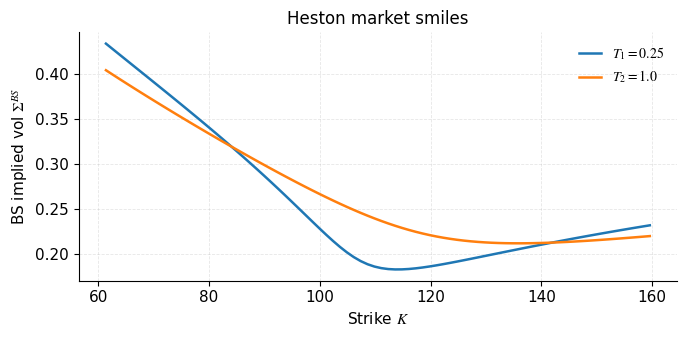

In [74]:
K_plot = np.linspace(qf_mu[1](0.01), qf_mu[2](0.99), 80)
fig, ax = plt.subplots(figsize=(7, 3.5))
for i, lbl in [(1, f"$T_1 = {T[1]}$"), (2, f"$T_2 = {T[2]}$")]:
    ax.plot(K_plot, heston.implied_vol(T[i], K_plot), label=lbl)
ax.set_xlabel("Strike $K$");  ax.set_ylabel("BS implied vol $\\Sigma^{BS}$")
ax.set_title("Heston market smiles");  ax.legend()
plt.tight_layout();  plt.show()

### 2. Transport map at $T_1$

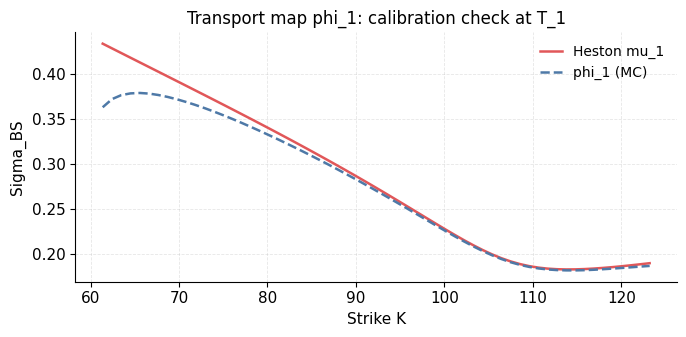

In [75]:
# Strike grids centred at s0 (absolute price space)
strikes_t1 = np.linspace(s0 - 11 + 0.001, s0 + 11 + 0.001, 2*10_000 + 3)
strikes_dt = np.linspace(s0 -  5 + 0.001, s0 +  5 + 0.001, 2* 2_000 + 3)
X_dt = strikes_dt[1:-1] - s0    # centred increment grid for A-operator

kernel_t1 = sabr.kernel(tau1,  strikes_t1)   # normalised SABR kernel over tau_1
kernel_dt = sabr.kernel(delta, strikes_dt)   # normalised SABR kernel over Delta_t

# Brenier map phi_1 = QF_{mu_1} o F_{SABR, tau_1}
sabr_cdf_t1  = sabr.cdf(tau1, strikes_t1)
phi1_vals    = qf_mu[1](np.clip(sabr_cdf_t1(strikes_t1[1:]), 1e-8, 1-1e-8))
phi1         = interp1d(strikes_t1[1:], phi1_vals, kind='linear', bounds_error=False,
                        fill_value=(phi1_vals[0], phi1_vals[-1]))

# Calibration check at T_1
S1_check = phi1(sabr.simulate_terminal(tau1, 250, 500_000, seed=0))
K1 = np.linspace(qf_mu[1](0.01), qf_mu[1](0.99), 60)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(K1, heston.implied_vol(T[1], K1),     color=C['market'], label='Heston mu_1')
ax.plot(K1, mc_iv(s0, T[1], K1, S1_check), '--', color=C['model'],  label='phi_1 (MC)')
ax.set_xlabel("Strike K");  ax.set_ylabel("Sigma_BS")
ax.set_title("Transport map phi_1: calibration check at T_1");  ax.legend()
plt.tight_layout();  plt.show()

### 3. A-operator fixed point — calibration at $T_2$

  iter  10  ||Delta F||_inf = 6.80e-04
  iter  20  ||Delta F||_inf = 6.80e-04
  iter  30  ||Delta F||_inf = 6.80e-04
  iter  40  ||Delta F||_inf = 6.80e-04
  iter  50  ||Delta F||_inf = 6.80e-04
  iter  60  ||Delta F||_inf = 6.80e-04


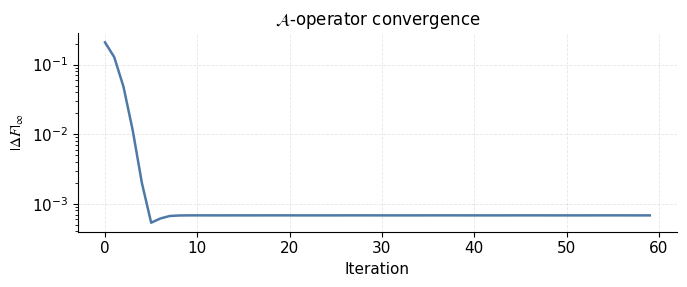

In [76]:
fill_lo = float(qf_mu[2](1e-8))
fill_hi = float(qf_mu[2](1 - 1e-8))

def A_operator(F):
    G = convolve(F, kernel_dt, 0.0, 1.0, mode='forward')
    H = qf_mu[2](np.clip(G, 1e-8, 1-1e-8))
    R = convolve(H, kernel_dt, fill_lo, fill_hi, mode='backward')
    return cdf_mu[1](R)

F0 = st.norm.cdf(X_dt, scale=np.sqrt(0.5*(T[1]+T[2])))   # initial guess
F_alpha, errors = fixed_point(A_operator, F0, tol=1e-5, max_iter=60)

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(errors, color=C['model'])
ax.set_xlabel("Iteration");  ax.set_ylabel("$\\|\\Delta F\\|_\\infty$")
ax.set_title("$\\mathcal{A}$-operator convergence")
plt.tight_layout();  plt.show()

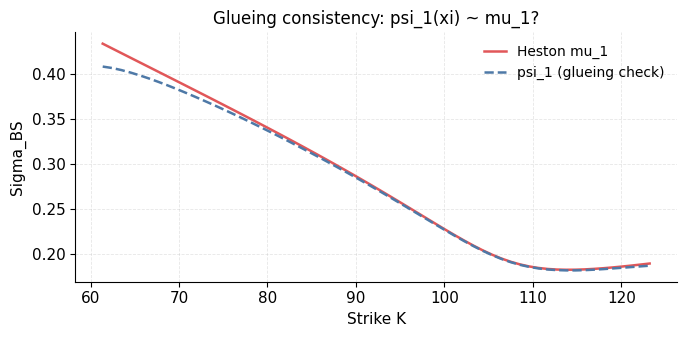

In [77]:
# Brenier map phi_2: push F_alpha forward under k_Delta, then apply QF_{mu_2}
phi2_vals = qf_mu[2](np.clip(
    convolve(F_alpha, kernel_dt, 0.0, 1.0, mode='forward'), 1e-8, 1-1e-8))
phi2    = interp1d(X_dt + s0, phi2_vals, kind='linear', bounds_error=False,
                   fill_value=(phi2_vals[0], phi2_vals[-1]))
Q_alpha = interp1d(F_alpha, X_dt + s0, kind='linear', bounds_error=False,
                   fill_value=(X_dt[0]+s0, X_dt[-1]+s0))

# Glueing consistency: psi_1(x) = E[phi_2(x + Z_Delta)] = backward convolution of phi_2
psi1_vals = convolve(phi2_vals, kernel_dt,
                     fill_left=phi2_vals[0], fill_right=phi2_vals[-1], mode='backward')
psi1      = interp1d(X_dt + s0, psi1_vals, kind='linear', bounds_error=False,
                     fill_value=(psi1_vals[0], psi1_vals[-1]))

# xi ~ F_alpha -> S_{T_1} = psi_1(xi) should match mu_1
xi_check = Q_alpha(np.random.default_rng(1).uniform(size=500_000))
K1 = np.linspace(qf_mu[1](0.01), qf_mu[1](0.99), 60)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(K1, heston.implied_vol(T[1], K1),           color=C['market'], label='Heston mu_1')
ax.plot(K1, mc_iv(s0, T[1], K1, psi1(xi_check)), '--', color=C['model'],  label='psi_1 (glueing check)')
ax.set_xlabel("Strike K");  ax.set_ylabel("Sigma_BS")
ax.set_title("Glueing consistency: psi_1(xi) ~ mu_1?");  ax.legend()
plt.tight_layout();  plt.show()

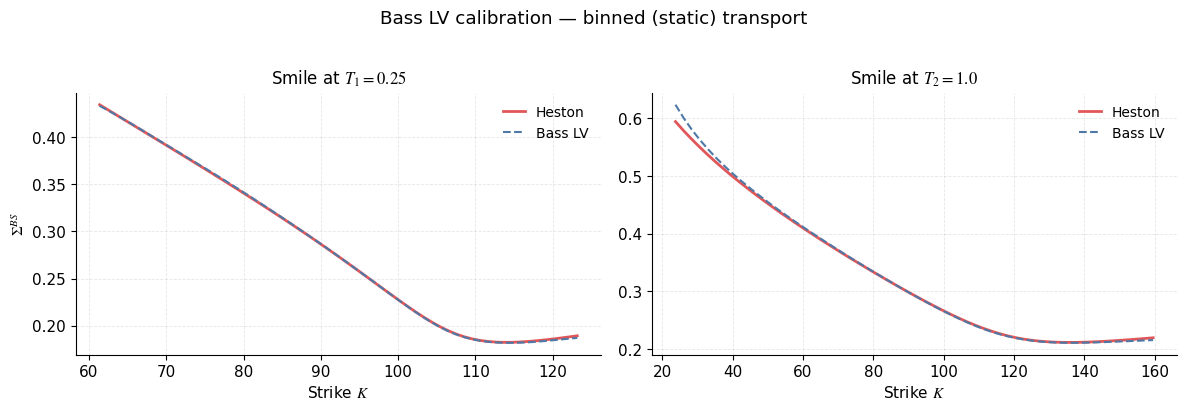

In [78]:
# Calibrated smiles at T₁ and T₂ via Monte Carlo
mc_n = 100_000
rng  = np.random.default_rng(42)

xi   = Q_alpha(rng.uniform(size=mc_n))
S1   = psi1(xi)
S2   = phi2(xi + sabr.simulate_terminal(delta, 500, mc_n, seed=7) - s0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (t_i, qf_i, S_mc, lbl) in zip(axes, [
        (T[1], qf_mu[1], S1, f"$T_1 = {T[1]}$"),
        (T[2], qf_mu[2], S2, f"$T_2 = {T[2]}$"),
]):
    K = np.linspace(qf_i(0.01), qf_i(0.99), 60)
    ax.plot(K, heston.implied_vol(t_i, K),   color=C['market'], lw=2,   label='Heston')
    ax.plot(K, mc_iv(s0, t_i, K, S_mc), '--', color=C['model'],  lw=1.5, label='Bass LV')
    ax.set_title(f"Smile at {lbl}");  ax.set_xlabel("Strike $K$");  ax.legend()
axes[0].set_ylabel("$\\Sigma^{BS}$")
plt.suptitle("Bass LV calibration — binned (static) transport", y=1.02)
plt.tight_layout();  plt.show()

### 4. Itô representation

Interval [0, T_1] - SABR paths + PDE + Ito transport
Solving PDE: Ny=181, Nu=111, Nt=63
  y in [97.500, 102.500]
  alpha in [0.0729, 3.4276]
  step 12/63
  step 24/63
  step 36/63
  step 48/63
  step 60/63


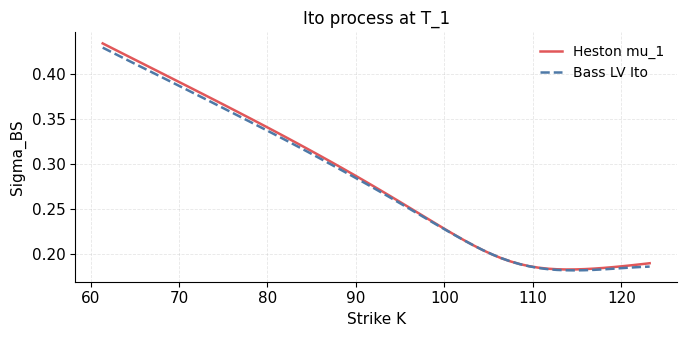

  X_T1: mean = 100.00,  std = 12.05


In [79]:
n_paths, n_steps_1 = 100_000, 63   # 63 approx 252 * T_1

print("Interval [0, T_1] - SABR paths + PDE + Ito transport")
Y1, A1, dW1, dZ1 = simulate_sabr(s0, sabr_alpha, sabr_nu, sabr_rho,
                                  tau1, n_paths, n_steps_1, seed=10)
sol1  = solve_pde_time_grid(
    StableNormalSABRPDE(nu=sabr_nu, rho=sabr_rho, T=tau1,
                        Ny=181, Nu=111, Nt=n_steps_1, y_width=10.0, u_width=5.5),
    g0=phi1, y0=s0, alpha=sabr_alpha)
X1 = apply_ito_transport(Y1, A1, dW1, dZ1, sol1, sabr_nu)

K1 = np.linspace(qf_mu[1](0.01), qf_mu[1](0.99), 60)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(K1, heston.implied_vol(T[1], K1),       color=C['market'], label='Heston mu_1')
ax.plot(K1, mc_iv(s0, T[1], K1, X1[:, -1]), '--', color=C['model'],  label='Bass LV Ito')
ax.set_xlabel("Strike K");  ax.set_ylabel("Sigma_BS")
ax.set_title("Ito process at T_1");  ax.legend()
plt.tight_layout();  plt.show()
print(f"  X_T1: mean = {X1[:,-1].mean():.2f},  std = {X1[:,-1].std():.2f}")

Interval [T_1, T_2] - SABR paths + PDE + Ito transport
Solving PDE: Ny=181, Nu=111, Nt=189
  y in [93.505, 106.495]
  alpha in [0.0178, 14.0279]
  step 37/189
  step 74/189
  step 111/189
  step 148/189
  step 185/189


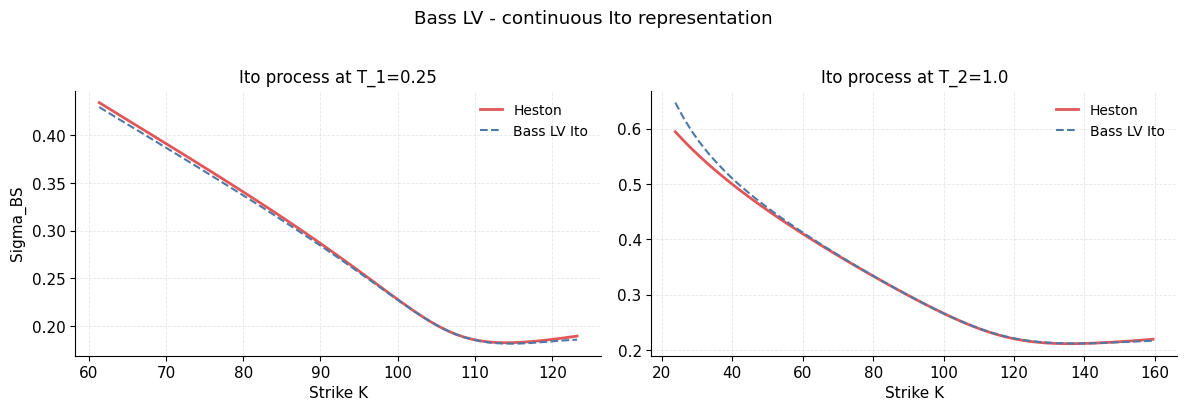

  X_T2: mean = 100.07,  std = 27.45


In [80]:
n_steps_2 = 189   # 189 approx 252 * Delta_t

# Glueing: invert psi_1 to recover xi for each path
psi1_inv = interp1d(psi1_vals, X_dt + s0, kind='linear', bounds_error=False,
                    fill_value=(X_dt[0]+s0, X_dt[-1]+s0))
xi_start = psi1_inv(X1[:, -1])

# Arithmetic SABR translation invariance: simulate from s0, then shift
print("Interval [T_1, T_2] - SABR paths + PDE + Ito transport")
Y2_base, A2, dW2, dZ2 = simulate_sabr(s0, sabr_alpha, sabr_nu, sabr_rho,
                                       delta, n_paths, n_steps_2, seed=20)
Y2   = Y2_base + (xi_start - s0)[:, np.newaxis]
sol2 = solve_pde_time_grid(
    StableNormalSABRPDE(nu=sabr_nu, rho=sabr_rho, T=delta,
                        Ny=181, Nu=111, Nt=n_steps_2, y_width=15.0, u_width=5.5),
    g0=phi2, y0=s0, alpha=sabr_alpha)
X2 = apply_ito_transport(Y2, A2, dW2, dZ2, sol2, sabr_nu)

# Combined smile check
K2 = np.linspace(qf_mu[2](0.01), qf_mu[2](0.99), 60)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (t_i, qf_i, X_term, lbl) in zip(axes, [
        (T[1], qf_mu[1], X1[:, -1], f"T_1={T[1]}"),
        (T[2], qf_mu[2], X2[:, -1], f"T_2={T[2]}"),
]):
    K = np.linspace(qf_i(0.01), qf_i(0.99), 60)
    ax.plot(K, heston.implied_vol(t_i, K),        color=C['market'], lw=2,   label='Heston')
    ax.plot(K, mc_iv(s0, t_i, K, X_term),    '--', color=C['model'],  lw=1.5, label='Bass LV Ito')
    ax.set_title(f"Ito process at {lbl}");  ax.set_xlabel("Strike K");  ax.legend()
axes[0].set_ylabel("Sigma_BS")
plt.suptitle("Bass LV - continuous Ito representation", y=1.02)
plt.tight_layout();  plt.show()
print(f"  X_T2: mean = {X2[:,-1].mean():.2f},  std = {X2[:,-1].std():.2f}")

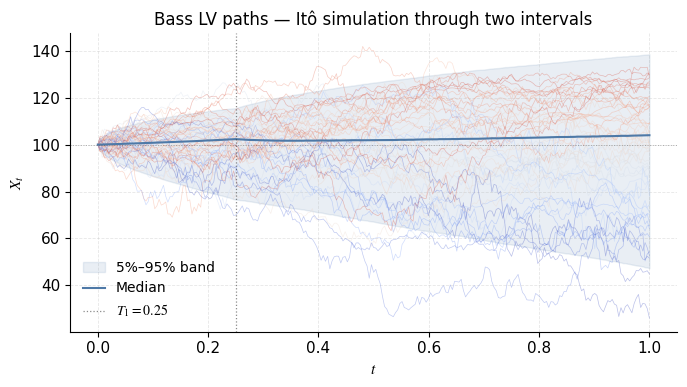

In [81]:
t_grid_1 = np.linspace(0.0, T[1], n_steps_1 + 1)
t_grid_2 = np.linspace(T[1], T[2], n_steps_2 + 1)
t_full = np.concatenate([t_grid_1, t_grid_2[1:]])
X_full = np.concatenate([X1, X2[:, 1:]], axis=1)

# Sample paths coloured by terminal value
idx = np.random.default_rng(7).choice(n_paths, 50, replace=False)
q05 = np.quantile(X_full, 0.05, axis=0)
q95 = np.quantile(X_full, 0.95, axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
for i in idx:
    c = plt.cm.coolwarm((X_full[i, -1] - q05[-1]) / (q95[-1] - q05[-1] + 1e-8))
    ax.plot(t_full, X_full[i], lw=0.5, alpha=0.35, color=c)
ax.fill_between(t_full, q05, q95, alpha=0.12, color=C['model'], label='5%–95% band')
ax.plot(t_full, np.median(X_full, axis=0), color=C['model'], lw=1.5, label='Median')
vline(ax, T[1], label=f'$T_1 = {T[1]}$')
ax.axhline(s0, color=C['dark'], lw=0.7, linestyle=':', alpha=0.35)
ax.set_xlabel("$t$");  ax.set_ylabel("$X_t$")
ax.set_title("Bass LV paths — Itô simulation through two intervals");  ax.legend()
plt.tight_layout();  plt.show()

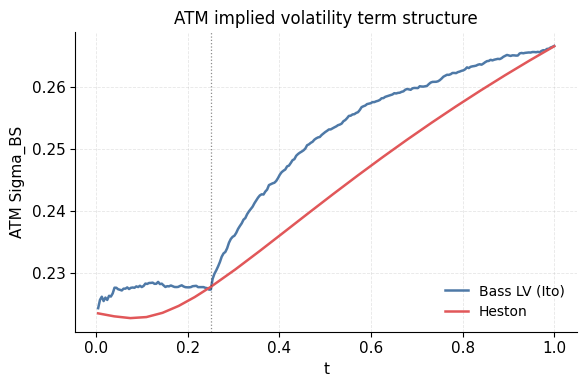

t=T_1: Bass LV 0.2274  |  Heston 0.2278
t=T_2: Bass LV 0.2665  |  Heston 0.2665


In [82]:
# ATM implied vol term structure (K = s0, X_t is a martingale)
call_prices = np.maximum(X_full - s0, 0).mean(axis=0)
atm_iv_bass = bs_implied_vol(s0, t_full[1:], s0, call_prices[1:])

# Heston ATM IV on a coarse grid (each call requires quadrature)
t_heston = np.concatenate([np.linspace(t_full[1], T[1], 8),
                            np.linspace(T[1], T[2], 15)[1:]])
heston_atm = heston.implied_vol(t_heston, s0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_full[1:], atm_iv_bass, color=C['model'],  label='Bass LV (Ito)')
ax.plot(t_heston,   heston_atm,  color=C['market'], label='Heston')
vline(ax, T[1])
ax.set_xlabel("t");  ax.set_ylabel("ATM Sigma_BS")
ax.set_title("ATM implied volatility term structure");  ax.legend()
plt.tight_layout();  plt.show()

idx_t1 = np.searchsorted(t_full[1:], T[1]) - 1
print(f"t=T_1: Bass LV {atm_iv_bass[idx_t1]:.4f}  |  Heston {heston.implied_vol(T[1], s0):.4f}")
print(f"t=T_2: Bass LV {atm_iv_bass[-1]:.4f}  |  Heston {heston.implied_vol(T[2], s0):.4f}")

Computing pathwise m'(t)...


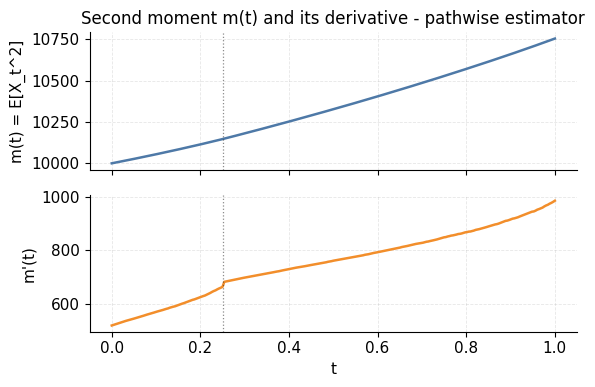

In [83]:
# m'(t) via pathwise differentiation (IPA): unbiased, no finite-difference noise
# d<X>_t = A_t^2*(f_y^2 + nu^2*f_a^2 + 2*rho*nu*f_y*f_a)*dt -> m'(t) = E[d<X>_t/dt]
print("Computing pathwise m'(t)...")
mp1 = pathwise_second_moment_deriv(Y1, A1, sol1, sabr_nu, sabr_rho)
mp2 = pathwise_second_moment_deriv(Y2, A2, sol2, sabr_nu, sabr_rho)
t_full_m, m_full, mp_full = second_moment_curve([mp1, mp2], [t_grid_1, t_grid_2], s0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
ax1.plot(t_full_m, m_full, color=C['model'])
vline(ax1, T[1]);  ax1.set_ylabel("m(t) = E[X_t^2]")
ax1.set_title("Second moment m(t) and its derivative - pathwise estimator")

ax2.plot(t_full_m, mp_full, color=C['aux'])
vline(ax2, T[1]);  ax2.set_xlabel("t");  ax2.set_ylabel("m'(t)")

plt.tight_layout();  plt.show()